# Butterfly Classification with TensorFlow/Keras
Notebook ini melatih dua pendekatan: **Simple CNN** dan **Transfer Learning InceptionV3** dengan TensorFlow/Keras.

Struktur dibuat per tahap: setiap penjelasan di markdown, lalu code di bawahnya.
Output dibuat ringkas (minimal print), dan implementasi mengikuti best practice Keras dari referensi Context7 (tf.data pipeline, callback training, transfer learning).

## 1. Setup Environment dan Import Library

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input as inception_preprocess

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)
AUTOTUNE = tf.data.AUTOTUNE
device_name = tf.config.list_physical_devices('GPU')
'GPU available' if device_name else 'CPU only'

2026-03-10 16:20:45.800140: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773159645.983270      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773159646.035660      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773159646.475318      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773159646.475365      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773159646.475367      24 computation_placer.cc:177] computation placer alr

'GPU available'

## 2. Konfigurasi Path Dataset `/archive` dan Hyperparameter
Dataset ini memakai gambar di folder flat `train/` dan `test/`, sedangkan label training ada di `Training_set.csv`.

In [2]:
from pathlib import Path

DATA_DIR = Path('/kaggle/input/datasets/phucthaiv02/butterfly-image-classification')

TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR = DATA_DIR / 'test'
TRAIN_CSV = DATA_DIR / 'Training_set.csv'
TEST_CSV = DATA_DIR / 'Testing_set.csv'

BATCH_SIZE = 32
VAL_SIZE = 0.2

EPOCHS_CNN = 50
EPOCHS_INCEPTION_HEAD = 25
EPOCHS_INCEPTION_FINETUNE = 25

LR_CNN = 1e-3
LR_INCEPTION_HEAD = 1e-3
LR_INCEPTION_FINETUNE = 1e-5

IMG_SIZE_CNN = 224
IMG_SIZE_INCEPTION = 299

WORK_DIR = Path('/kaggle/working')
CHECKPOINT_DIR = WORK_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

SIMPLE_CNN_CKPT = CHECKPOINT_DIR / 'best_simple_cnn.keras'
INCEPTION_CKPT = CHECKPOINT_DIR / 'best_inception_v3.keras'

PRED_CSV_PATH = WORK_DIR / 'test_predictions_tf.csv'
FINAL_MODEL_PATH = CHECKPOINT_DIR / 'best_final_model.keras'

TRAIN_DIR.exists(), TEST_DIR.exists(), TRAIN_CSV.exists(), TEST_CSV.exists()

(True, True, True, True)

## 3. Definisi Preprocessing dan Augmentasi Data
Train memakai augmentasi ringan. Untuk transfer learning InceptionV3, preprocessing memakai `keras.applications.inception_v3.preprocess_input`.

In [3]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def decode_and_resize(path, label, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (img_size, img_size))
    img = tf.cast(img, tf.float32)
    return img, label

def preprocess_for_simplecnn(path, label, training=False):
    img, label = decode_and_resize(path, label, IMG_SIZE_CNN)
    if training:
        img = data_augmentation(img, training=True)
    img = img / 255.0
    return img, label

def preprocess_for_inception(path, label, training=False):
    img, label = decode_and_resize(path, label, IMG_SIZE_INCEPTION)
    if training:
        img = data_augmentation(img, training=True)
    img = inception_preprocess(img)
    return img, label

I0000 00:00:1773159668.380127      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 4. Load Dataset Train/Test dengan `tf.data`
Karena struktur gambar flat, label diambil dari CSV lalu dibangun jadi pipeline `tf.data` yang efisien (`cache`, `shuffle`, `prefetch`).

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

class_names = sorted(train_df['label'].unique().tolist())
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}
num_classes = len(class_names)

train_df = train_df.copy()
train_df['label_idx'] = train_df['label'].map(class_to_idx)

try:
    tr_df, val_df = train_test_split(
        train_df,
        test_size=VAL_SIZE,
        random_state=42,
        stratify=train_df['label_idx']
    )
except ValueError:
    tr_df, val_df = train_test_split(
        train_df,
        test_size=VAL_SIZE,
        random_state=42,
        stratify=None
    )

tr_df = tr_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

def make_paths_and_labels(df, image_dir, with_label=True):
    paths = (image_dir / df['filename']).astype(str).values
    if with_label:
        labels = df['label_idx'].astype('int32').values
        return paths, labels
    return paths

train_paths, train_labels = make_paths_and_labels(tr_df, TRAIN_DIR)
val_paths, val_labels = make_paths_and_labels(val_df, TRAIN_DIR)
test_paths = make_paths_and_labels(test_df, TEST_DIR, with_label=False)

def build_dataset(paths, labels=None, preprocess_fn=None, training=False):
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices((paths, tf.zeros(len(paths), dtype=tf.int32)))
    else:
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(min(len(paths), 2048), reshuffle_each_iteration=True)

    ds = ds.map(lambda x, y: preprocess_fn(x, y, training=training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

## 5. Inspect Class Mapping dan Contoh Batch
Verifikasi mapping label, ukuran split, dan dimensi tensor sebelum training.

{'num_classes': 75, 'train_size': 5199, 'val_size': 1300, 'test_size': 2786}
sample class_to_idx: {'ADONIS': 0, 'AFRICAN GIANT SWALLOWTAIL': 1, 'AMERICAN SNOOT': 2, 'AN 88': 3, 'APPOLLO': 4, 'ATALA': 5, 'BANDED ORANGE HELICONIAN': 6, 'BANDED PEACOCK': 7}


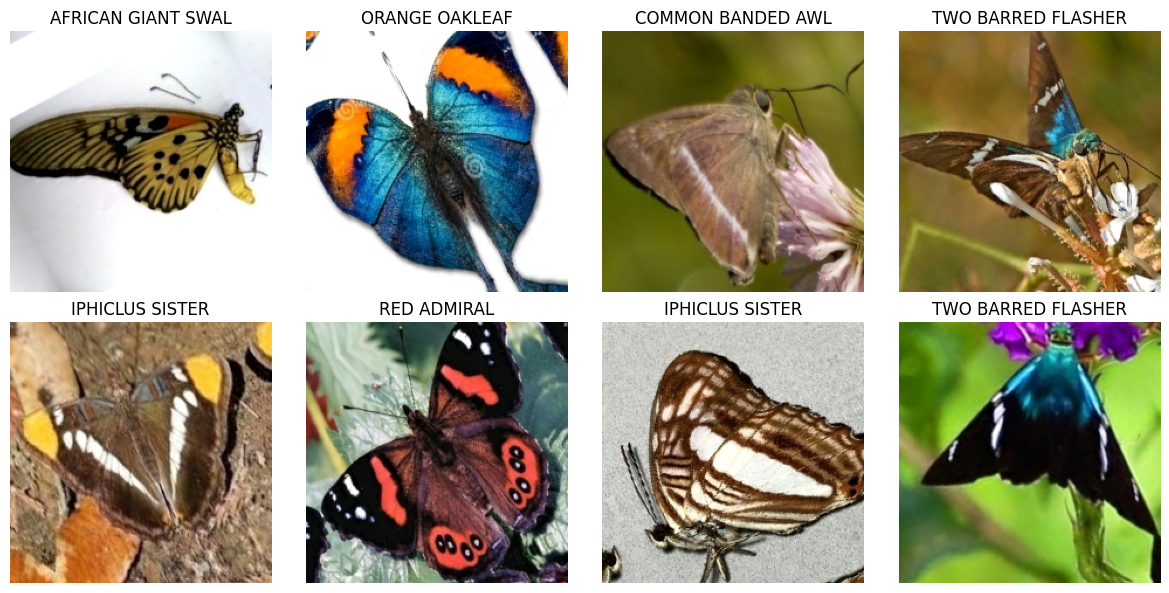

In [5]:
train_ds_cnn = build_dataset(train_paths, train_labels, preprocess_for_simplecnn, training=True)
val_ds_cnn = build_dataset(val_paths, val_labels, preprocess_for_simplecnn, training=False)
test_ds_cnn = build_dataset(test_paths, None, preprocess_for_simplecnn, training=False)

print({'num_classes': num_classes, 'train_size': len(tr_df), 'val_size': len(val_df), 'test_size': len(test_df)})
print('sample class_to_idx:', dict(list(class_to_idx.items())[:8]))

images, labels = next(iter(train_ds_cnn))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):
    img = tf.clip_by_value(images[i], 0.0, 1.0).numpy()
    ax.imshow(img)
    ax.set_title(idx_to_class[int(labels[i])][:18])
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Definisi Arsitektur Simple CNN (Keras)

In [6]:
def build_simple_cnn(num_classes: int):
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE_CNN, IMG_SIZE_CNN, 3)),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='simple_cnn')

    model.compile(
        optimizer=keras.optimizers.Adam(LR_CNN),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

simple_cnn = build_simple_cnn(num_classes)
simple_cnn.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 75)             │         9,675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,819 (405.54 KB)

 Trainable params: 103,371 (403.79 KB)

 Non-trainable params: 448 (1.75 KB)

## 7. Training Simple CNN
Training menggunakan callback best practice: `ModelCheckpoint`, `EarlyStopping`, dan `ReduceLROnPlateau`.

In [7]:
callbacks_cnn = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(SIMPLE_CNN_CKPT),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history_cnn = simple_cnn.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=EPOCHS_CNN,
    callbacks=callbacks_cnn,
    verbose=1
)

best_val_acc_cnn = float(np.max(history_cnn.history['val_accuracy']))
best_val_acc_cnn

Epoch 1/50


I0000 00:00:1773159675.652185      67 service.cc:152] XLA service 0x4860a040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773159675.652225      67 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773159676.251999      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/163 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.0174 - loss: 4.5630     

I0000 00:00:1773159681.148320      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.0656 - loss: 4.0702
Epoch 1: val_accuracy improved from -inf to 0.01385, saving model to /kaggle/working/checkpoints/best_simple_cnn.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 46s 233ms/step - accuracy: 0.0658 - loss: 4.0687 - val_accuracy: 0.0138 - val_loss: 4.7658 - learning_rate: 0.0010
Epoch 2/50
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.1590 - loss: 3.3733
Epoch 2: val_accuracy did not improve from 0.01385
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - accuracy: 0.1593 - loss: 3.3720 - val_accuracy: 0.0138 - val_loss: 5.2897 - learning_rate: 0.0010
Epoch 3/50
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.2612 - loss: 2.9431
Epoch 3: val_accuracy improved from 0.01385 to 0.05077, saving model to /kaggle/working/checkpoints/best_simple_cnn.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.2614 - loss: 2.9423 - val_accuracy: 0.0508 - val_loss: 4.3568 - learning_rate: 0.0010
Epoch 4/50
163/163 ━━━━

0.6969230771064758

## 8. Evaluasi Simple CNN (Validation Set)
`Testing_set.csv` tidak punya label, jadi evaluasi metrik klasifikasi dilakukan di validation set.

SimpleCNN Validation Accuracy: 0.6969
                           precision    recall  f1-score   support

                   ADONIS       0.76      0.89      0.82        18
AFRICAN GIANT SWALLOWTAIL       0.83      0.67      0.74        15
           AMERICAN SNOOT       0.48      0.73      0.58        15
                    AN 88       1.00      0.82      0.90        17
                  APPOLLO       0.62      0.83      0.71        18
                    ATALA       0.95      0.90      0.92        20
 BANDED ORANGE HELICONIAN       1.00      0.75      0.86        20
           BANDED PEACOCK       0.59      0.76      0.67        17
            BECKERS WHITE       0.44      0.50      0.47        16
         BLACK HAIRSTREAK       0.62      0.47      0.53        17
              BLUE MORPHO       0.82      0.60      0.69        15
        BLUE SPOTTED CROW       0.79      0.65      0.71        17
           BROWN SIPROETA       0.70      0.80      0.74        20
            CABBAGE WHI

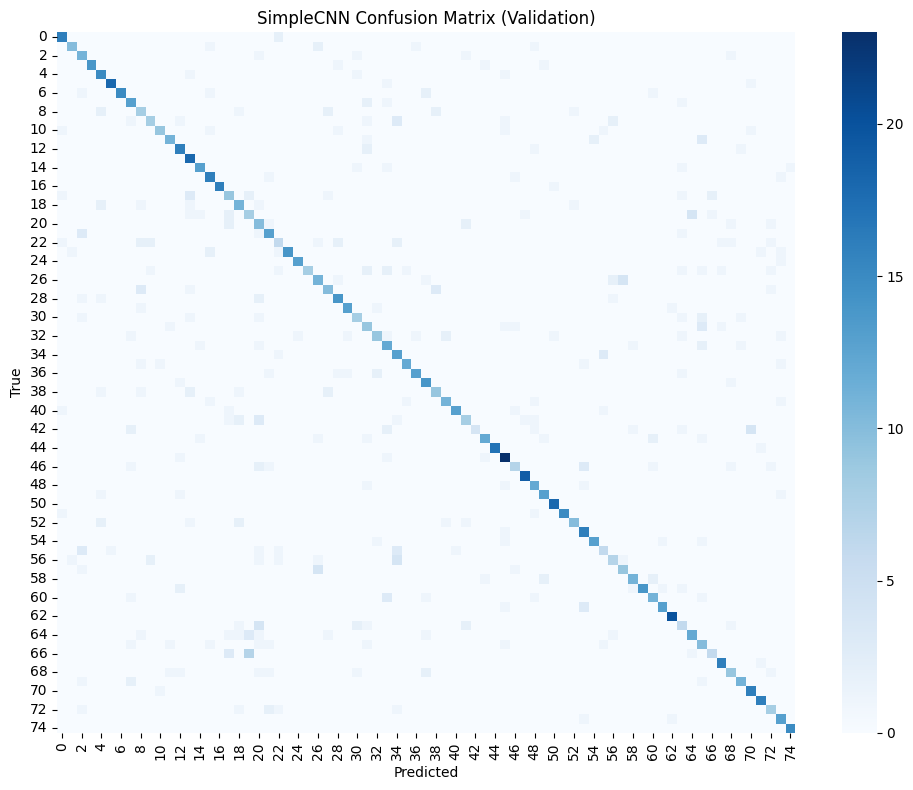

In [8]:
val_probs_cnn = simple_cnn.predict(val_ds_cnn, verbose=0)
y_pred_cnn = val_probs_cnn.argmax(axis=1)
y_true_cnn = val_labels

acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
print(f"SimpleCNN Validation Accuracy: {acc_cnn:.4f}")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names, zero_division=0))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, cmap='Blues')
plt.title('SimpleCNN Confusion Matrix (Validation)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 9. Definisi Transfer Learning InceptionV3 (Pretrained)
Tahap awal: freeze backbone InceptionV3, train classifier head dulu.

In [9]:
train_ds_inc = build_dataset(train_paths, train_labels, preprocess_for_inception, training=True)
val_ds_inc = build_dataset(val_paths, val_labels, preprocess_for_inception, training=False)
test_ds_inc = build_dataset(test_paths, None, preprocess_for_inception, training=False)

base_model = InceptionV3(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION, 3)
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

inception_model = keras.Model(inputs, outputs, name='inception_v3_transfer')
inception_model.compile(
    optimizer=keras.optimizers.Adam(LR_INCEPTION_HEAD),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

inception_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "inception_v3_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 75)             │       153,675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,956,459 (83.76 MB)

 Trainable params: 153,675 (600.29 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

## 10. Training InceptionV3 (Head Training + Fine-tuning Ringan)
Best practice transfer learning: train head dulu, lalu unfreeze sebagian backbone dengan learning rate kecil.

In [10]:
callbacks_inc = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(INCEPTION_CKPT),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_inc_head = inception_model.fit(
    train_ds_inc,
    validation_data=val_ds_inc,
    epochs=EPOCHS_INCEPTION_HEAD,
    callbacks=callbacks_inc,
    verbose=1
)

base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

inception_model.compile(
    optimizer=keras.optimizers.Adam(LR_INCEPTION_FINETUNE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_inc_ft = inception_model.fit(
    train_ds_inc,
    validation_data=val_ds_inc,
    epochs=EPOCHS_INCEPTION_FINETUNE,
    callbacks=callbacks_inc,
    verbose=1
)

best_val_acc_inc = max(
    float(np.max(history_inc_head.history['val_accuracy'])),
    float(np.max(history_inc_ft.history['val_accuracy']))
)
best_val_acc_inc

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.1895 - loss: 3.5599
Epoch 1: val_accuracy improved from -inf to 0.56000, saving model to /kaggle/working/checkpoints/best_inception_v3.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 356ms/step - accuracy: 0.1905 - loss: 3.5555 - val_accuracy: 0.5600 - val_loss: 1.9463 - learning_rate: 0.0010
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.6084 - loss: 1.6962
Epoch 2: val_accuracy improved from 0.56000 to 0.69538, saving model to /kaggle/working/checkpoints/best_inception_v3.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 230ms/step - accuracy: 0.6087 - loss: 1.6953 - val_accuracy: 0.6954 - val_loss: 1.3652 - learning_rate: 0.0010
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.7377 - loss: 1.1990
Epoch 3: val_accuracy improved from 0.69538 to 0.72231, saving model to /kaggle/working/checkpoints/best_inception_v3.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 233ms/step - accuracy: 0.7377 - loss: 1.1986 -

0.8961538672447205

## 11. Evaluasi InceptionV3 dan Perbandingan Hasil Model

InceptionV3 Validation Accuracy: 0.8962
                           precision    recall  f1-score   support

                   ADONIS       0.90      1.00      0.95        18
AFRICAN GIANT SWALLOWTAIL       1.00      0.87      0.93        15
           AMERICAN SNOOT       0.94      1.00      0.97        15
                    AN 88       1.00      0.94      0.97        17
                  APPOLLO       0.94      0.94      0.94        18
                    ATALA       0.95      1.00      0.98        20
 BANDED ORANGE HELICONIAN       0.95      0.95      0.95        20
           BANDED PEACOCK       0.89      0.94      0.91        17
            BECKERS WHITE       0.70      0.88      0.78        16
         BLACK HAIRSTREAK       0.86      0.71      0.77        17
              BLUE MORPHO       0.92      0.80      0.86        15
        BLUE SPOTTED CROW       1.00      0.88      0.94        17
           BROWN SIPROETA       0.95      0.90      0.92        20
            CABBAGE W

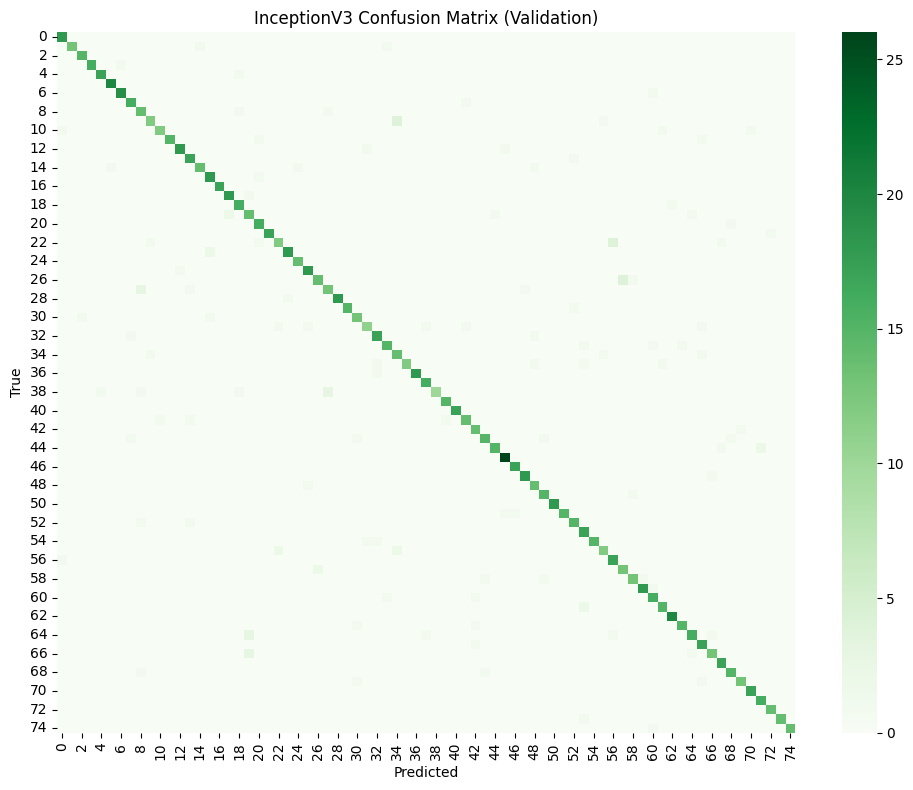

,model,val_accuracy,best_val_during_training
0,SimpleCNN,0.696923,0.696923
1,InceptionV3,0.896154,0.896154


In [11]:
inception_model = keras.models.load_model(INCEPTION_CKPT)

val_probs_inc = inception_model.predict(val_ds_inc, verbose=0)
y_pred_inc = val_probs_inc.argmax(axis=1)
y_true_inc = val_labels

acc_inc = accuracy_score(y_true_inc, y_pred_inc)
print(f"InceptionV3 Validation Accuracy: {acc_inc:.4f}")
print(classification_report(y_true_inc, y_pred_inc, target_names=class_names, zero_division=0))

cm_inc = confusion_matrix(y_true_inc, y_pred_inc)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_inc, cmap='Greens')
plt.title('InceptionV3 Confusion Matrix (Validation)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

compare_df = pd.DataFrame({
    'model': ['SimpleCNN', 'InceptionV3'],
    'val_accuracy': [acc_cnn, acc_inc],
    'best_val_during_training': [best_val_acc_cnn, best_val_acc_inc],
})
compare_df

## 12. Inferensi pada Data Test dan Simpan Prediksi/Model
Model terbaik dipilih dari validation accuracy, lalu dipakai untuk prediksi `Testing_set.csv`.

In [12]:
if acc_inc >= acc_cnn:
    best_name = 'InceptionV3'
    best_model = keras.models.load_model(INCEPTION_CKPT)
    best_test_ds = test_ds_inc
else:
    best_name = 'SimpleCNN'
    best_model = keras.models.load_model(SIMPLE_CNN_CKPT)
    best_test_ds = test_ds_cnn

probs = best_model.predict(best_test_ds, verbose=0)
pred_idx = probs.argmax(axis=1)
conf = probs.max(axis=1)

pred_df = pd.DataFrame({
    'filename': test_df['filename'].values,
    'label': [idx_to_class[int(i)] for i in pred_idx],
    'confidence': conf,
})
pred_df.to_csv(PRED_CSV_PATH, index=False)

best_model.save(FINAL_MODEL_PATH)

print({'best_model': best_name, 'prediction_csv': str(PRED_CSV_PATH), 'final_model': str(FINAL_MODEL_PATH)})
pred_df.head()

{'best_model': 'InceptionV3', 'prediction_csv': '/kaggle/working/test_predictions_tf.csv', 'final_model': '/kaggle/working/checkpoints/best_final_model.keras'}


,filename,label,confidence
0,Image_1.jpg,PINE WHITE,0.999701
1,Image_2.jpg,CRIMSON PATCH,0.999043
2,Image_3.jpg,ADONIS,0.988518
3,Image_4.jpg,IPHICLUS SISTER,0.652633
4,Image_5.jpg,MILBERTS TORTOISESHELL,0.964059
